In [1]:
import pandas as pd
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np  # likely needed too

# Clear and rebuild cache
import shutil, os
cache = matplotlib.get_cachedir()
shutil.rmtree(cache, ignore_errors=True)
os.makedirs(cache, exist_ok=True)

# Manually register DejaVu fonts
font_dir = "/opt/homebrew/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf"
for ttf in os.listdir(font_dir):
    if ttf.endswith(".ttf"):
        fm.fontManager.addfont(os.path.join(font_dir, ttf))

# Set as default
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("Fonts loaded, good to go!")


Fonts loaded, good to go!


## Pretraining

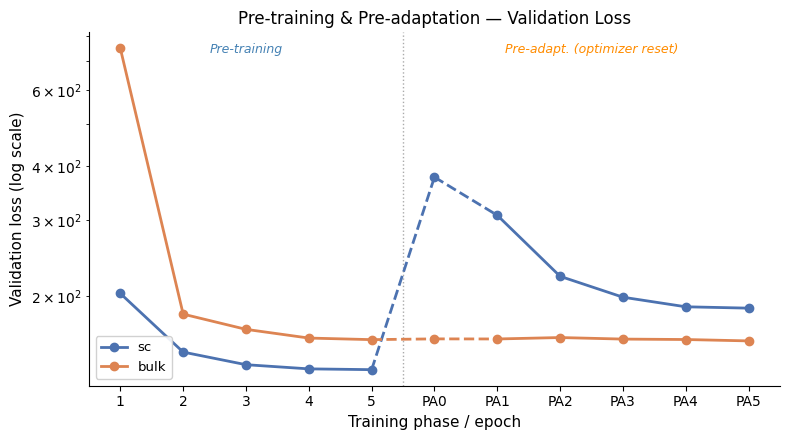

In [2]:
root = os.path.expanduser("~/Thesis/eheiss/output")

def load_val(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    val = df[df["split"] == "val"].reset_index(drop=True)
    return val if not val.empty else None

series = {
    "sc": {
        "pretrain": load_val(f"{root}/pretrain_sc/pretrain_sc_pretrain_epoch_metrics.csv"),
        "pa0": load_val(f"{root}/preadapt_sc/preadapt_sc_pa0_epoch_metrics.csv"),
        "preadapt": load_val(f"{root}/preadapt_sc/preadapt_sc_pretrain_epoch_metrics.csv"),
        "color": "#4C72B0",
    },
    "bulk": {
        "pretrain": load_val(f"{root}/pretrain_bulk/pretrain_bulk_pretrain_epoch_metrics.csv"),
        "pa0": load_val(f"{root}/preadapt_bulk/preadapt_bulk_pa0_epoch_metrics.csv"),
        "preadapt": load_val(f"{root}/preadapt_bulk/preadapt_bulk_pretrain_epoch_metrics.csv"),
        "color": "#DD8452",
    },
}
series = {name: values for name, values in series.items()
          if any(values[key] is not None for key in ("pretrain", "pa0", "preadapt"))}
if not series:
    raise FileNotFoundError(f"No pre-training, PA0, or pre-adaptation metric files found under {root}")

pretrain_epochs = sorted({epoch for values in series.values()
                          if values["pretrain"] is not None
                          for epoch in values["pretrain"]["epoch"]})
pretrain_end = max(pretrain_epochs, default=0)
has_pa0 = any(values["pa0"] is not None for values in series.values())
pa0_tick = pretrain_end + 1 if has_pa0 else None
preadapt_epochs = sorted({epoch for values in series.values()
                          if values["preadapt"] is not None
                          for epoch in values["preadapt"]["epoch"]})
preadapt_offset = pretrain_end + (1 if has_pa0 else 0)
preadapt_ticks = [preadapt_offset + epoch for epoch in preadapt_epochs]
sep = pretrain_end + 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))

for name, values in series.items():
    df_pt = values["pretrain"]
    df_pa0 = values["pa0"]
    df_pa = values["preadapt"]
    color = values["color"]
    last_x = None
    last_y = None

    if df_pt is not None:
        ax.plot(df_pt["epoch"], df_pt["loss"], color=color, marker="o",
                lw=2, zorder=3, label=name)
        last_x = float(df_pt["epoch"].iloc[-1])
        last_y = float(df_pt["loss"].iloc[-1])

    if df_pa0 is not None and pa0_tick is not None:
        pa0_loss = float(df_pa0["loss"].iloc[0])
        if last_x is not None:
            ax.plot([last_x, pa0_tick], [last_y, pa0_loss],
                    color=color, lw=2, ls="--", zorder=3)
        ax.plot([pa0_tick], [pa0_loss], color=color, marker="o", lw=0, zorder=4,
                label=name if df_pt is None else "_nolegend_")
        last_x = float(pa0_tick)
        last_y = pa0_loss

    if df_pa is not None:
        pa_x = preadapt_offset + df_pa["epoch"].to_numpy()
        if last_x is not None:
            ax.plot([last_x, pa_x[0]], [last_y, df_pa["loss"].iloc[0]],
                    color=color, lw=2, ls="--", zorder=3)
        ax.plot(pa_x, df_pa["loss"], color=color, marker="o", lw=2, zorder=3,
                label=name if df_pt is None and df_pa0 is None else "_nolegend_")

if pretrain_epochs and (has_pa0 or preadapt_epochs):
    ax.axvline(sep, color="#aaaaaa", ls=":", lw=1)
if pretrain_epochs:
    ax.text(np.mean(pretrain_epochs), 0.97, "Pre-training",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=9, color="steelblue", style="italic")
pa_phase_ticks = ([pa0_tick] if pa0_tick is not None else []) + preadapt_ticks
if pa_phase_ticks:
    ax.text(np.mean(pa_phase_ticks), 0.97, "Pre-adapt. (optimizer reset)",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=9, color="darkorange", style="italic")

xticks = pretrain_epochs + ([pa0_tick] if pa0_tick is not None else []) + preadapt_ticks
xlabels = [str(e) for e in pretrain_epochs] + (["PA0"] if pa0_tick is not None else []) + [f"PA{e}" for e in preadapt_epochs]
ax.set_yscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Training phase / epoch", fontsize=11)
ax.set_ylabel("Validation loss (log scale)", fontsize=11)
ax.set_title("Pre-training & Pre-adaptation — Validation Loss", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Cancer classification (5 types)

In [3]:
bulkrnabert_weighted_f1_mean = 0.993
bulkrnabert_weighted_f1_sd = 0.004


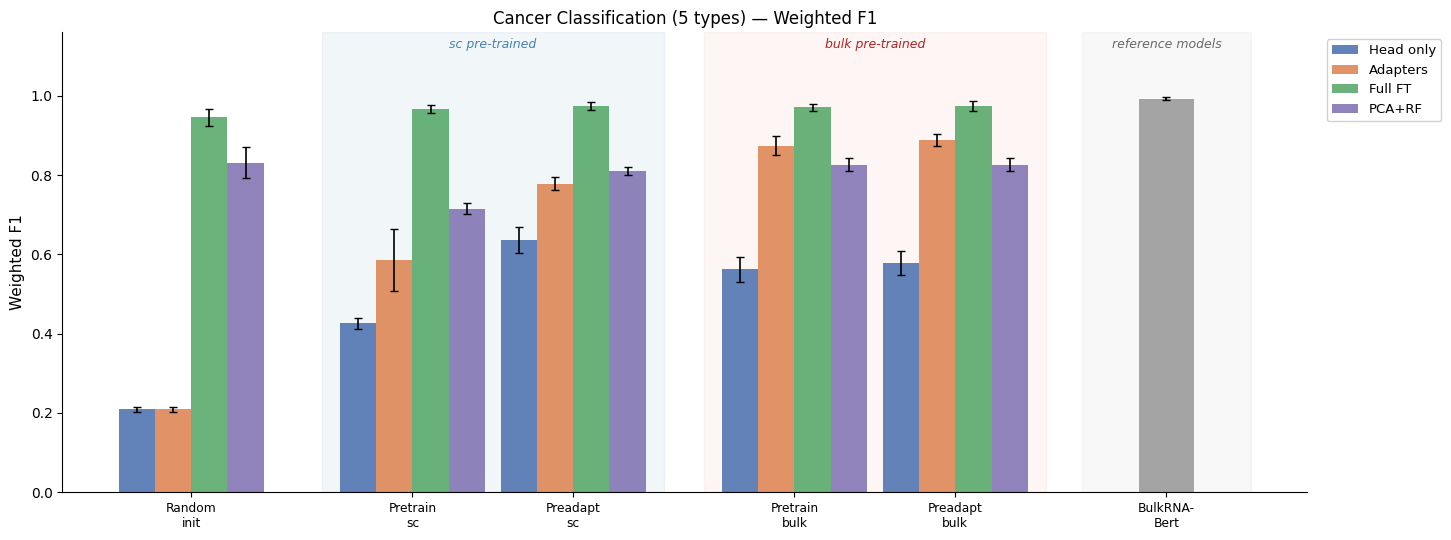

In [4]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nHVG"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]

def load_eval_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    df = load_eval_csv(combined)
    if df is not None:
        return df
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


def load_variant_metrics(specs, metric_col):
    loaded = {}
    for spec in specs:
        canonical = spec[0]
        path = f"{base}/{canonical}/{task}_{canonical}_evaluation_metrics.csv"
        df = load_eval_csv(path)
        if df is not None and metric_col in df.columns:
            loaded[canonical] = df
    return loaded


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = load_variant_metrics(baseline_specs, metric_mean)
large_fm_dfs = load_variant_metrics(large_fm_specs, metric_mean)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_dfs]
available_large_fms = [variant for variant, _label in large_fm_specs if variant in large_fm_dfs]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.18
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
baseline_start = 5.0
baseline_spacing = 0.78
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
large_fm_start = (max(baseline_x.values()) + 0.95) if baseline_x else 5.0
large_fm_spacing = 0.78
large_fm_x = {variant: large_fm_start + i * large_fm_spacing for i, variant in enumerate(available_large_fms)}
rightmost_nonref = max(
    list(baseline_x.values())
    + list(large_fm_x.values())
    + [centers["preadapt_bulk"]]
)
brnabert_x = rightmost_nonref + 1.05

fig, ax = plt.subplots(figsize=(17, 5.5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        df = dfs[mode]
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in baseline_dfs:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for variant, label in large_fm_specs:
    if variant not in large_fm_dfs or variant not in large_fm_x:
        continue
    row = large_fm_dfs[variant].loc["raw_mlp"] if "raw_mlp" in large_fm_dfs[variant].index else large_fm_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(large_fm_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8172B3", alpha=0.88,
           label="_nolegend_",
           error_kw={"linewidth": 1.2})

ax.bar(brnabert_x, bulkrnabert_weighted_f1_mean, bar_w * 1.5,
       yerr=bulkrnabert_weighted_f1_sd, capsize=3,
       color="#999999", alpha=0.88, label="_nolegend_")

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
baseline_lo = (min(baseline_x.values()) - 0.42) if baseline_x else None
baseline_hi = (max(baseline_x.values()) + 0.42) if baseline_x else None
large_fm_lo = (min(large_fm_x.values()) - 0.42) if large_fm_x else None
large_fm_hi = (max(large_fm_x.values()) + 0.42) if large_fm_x else None
ref_lo, ref_hi = brnabert_x - 0.42, brnabert_x + 0.42
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
if large_fm_x:
    ax.axvspan(large_fm_lo, large_fm_hi, alpha=0.07, color="#8172B3", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.16)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.015, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.015, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.015, "baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")
if large_fm_x:
    ax.text((large_fm_lo + large_fm_hi) / 2, y_lim[1] - 0.015, "large FMs", ha="center", va="top", fontsize=9, color="#8172B3", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.015, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

large_fm_label_map = {variant: label for variant, label in large_fm_specs}
tick_pos = (
    list(centers.values())
    + list(baseline_x.values())
    + [large_fm_x[v] for v in available_large_fms]
    + [brnabert_x]
)
tick_labels = (
    ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"]
    + [dict(baseline_specs)[v] for v in available_baselines]
    + [large_fm_label_map[v] for v in available_large_fms]
    + ["BulkRNA-\nBert"]
)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.8)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (5 types) — Weighted F1", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()


## Cancer classification (33 types)

In [5]:
bulkrnabert_weighted_f1_mean = 0.942
bulkrnabert_weighted_f1_sd = 0.004
bulkformer_weighted_f1_mean = 0.833
geneformer_weighted_f1_mean = 0.473
genecompass_weighted_f1_mean = 0.761
scgpt_weighted_f1_mean = 0.83
scfoundation_weighted_f1_mean = 0.791
sclong_weighted_f1_mean = 0.347


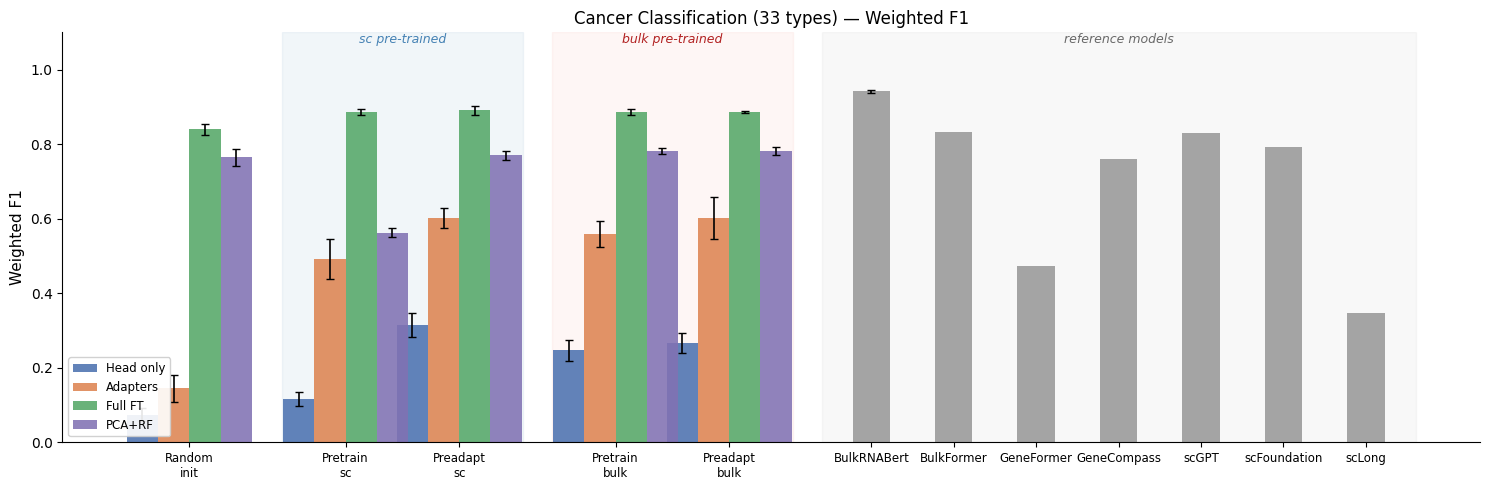

In [6]:
task = "canc_type_class_33"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

ref_models = [
    ("BulkRNABert",  bulkrnabert_weighted_f1_mean,  bulkrnabert_weighted_f1_sd),
    ("BulkFormer",   bulkformer_weighted_f1_mean,   None),
    ("GeneFormer",   geneformer_weighted_f1_mean,   None),
    ("GeneCompass",  genecompass_weighted_f1_mean,  None),
    ("scGPT",        scgpt_weighted_f1_mean,        None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong",       sclong_weighted_f1_mean,        None),
]
ref_start = (max(baseline_x.values()) + 0.9) if baseline_x else 4.8
ref_spacing = 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw-expression baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.003, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (33 types) — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Deconvolution

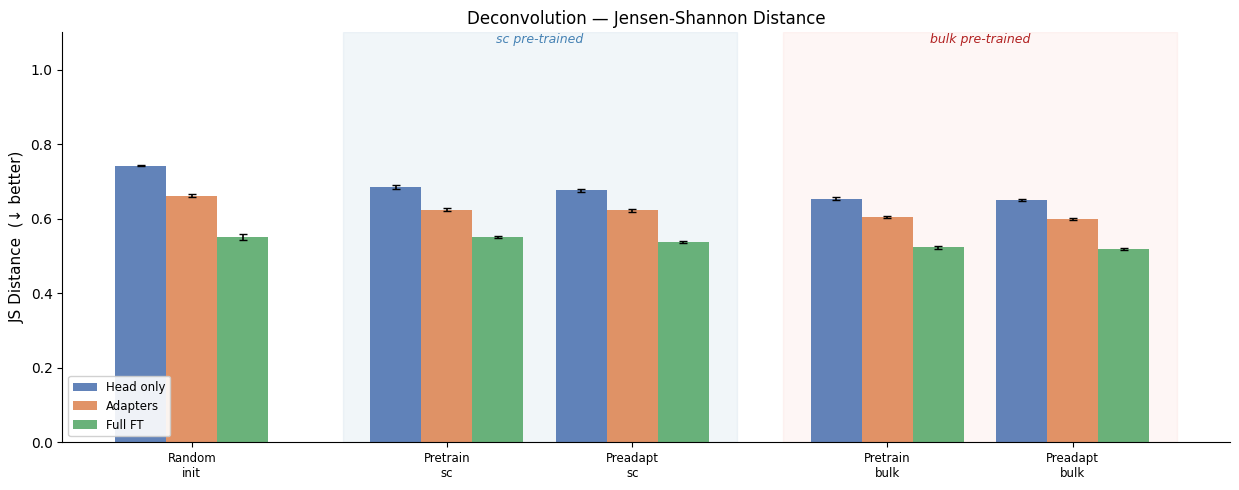

In [7]:
task = "deconv"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "js_distance_mean"
metric_std = "js_distance_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

fig, ax = plt.subplots(figsize=(12.5, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Raw MLP baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw MLP baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values())
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("JS Distance  (↓ better)", fontsize=11)
ax.set_title("Deconvolution — Jensen-Shannon Distance", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Disease classification

In [8]:
bulkformer_weighted_f1_mean = 0.939
geneformer_weighted_f1_mean = 0.749
genecompass_weighted_f1_mean = 0.882
scgpt_weighted_f1_mean = 0.885
scfoundation_weighted_f1_mean = 0.874
sclong_weighted_f1_mean = 0.81


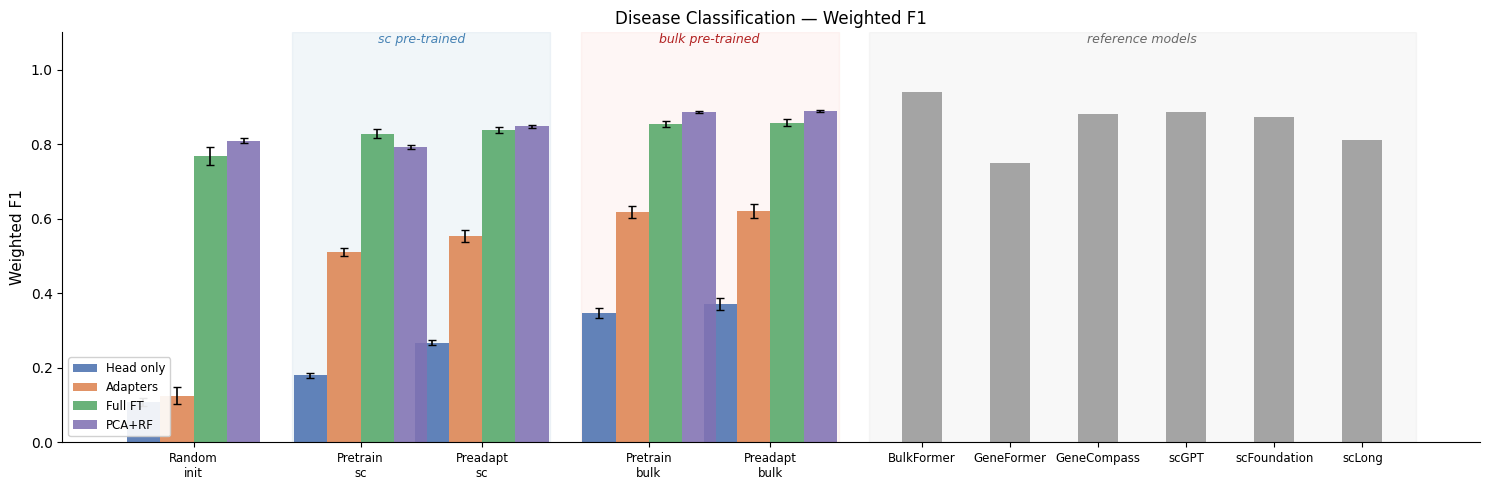

In [9]:
task = "disease_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

ref_models = [
    ("BulkFormer",   bulkformer_weighted_f1_mean,   None),
    ("GeneFormer",   geneformer_weighted_f1_mean,   None),
    ("GeneCompass",  genecompass_weighted_f1_mean,  None),
    ("scGPT",        scgpt_weighted_f1_mean,        None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong",       sclong_weighted_f1_mean,        None),
]
ref_start = (max(baseline_x.values()) + 0.9) if baseline_x else 4.8
ref_spacing = 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw-expression baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.003, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Disease Classification — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Drug response prediction

In [10]:
bulkformer_pcc_mean = 0.91
geneformer_pcc_mean = 0.873
genecompass_pcc_mean = 0.872
scgpt_pcc_mean = 0.877
scfoundation_pcc_mean = 0.88
sclong_pcc_mean = 0.843


In [12]:
task = "drug_resp"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "global_pcc_mean"
metric_std = "global_pcc_std"
baseline_specs = [
    ("raw_mlp_drug_only", "Drug-only\nMLP"),
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

ref_models = [
    ("BulkFormer",   bulkformer_pcc_mean,   None),
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scGPT",        scgpt_pcc_mean,        None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
ref_start = (max(baseline_x.values()) + 0.9) if baseline_x else 4.8
ref_spacing = 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Raw MLP baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw MLP baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.003, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("PCC (global)", fontsize=11)
ax.set_title("Drug Response Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


FileNotFoundError: No evaluation metric files found under /Users/enricoheiss/Thesis/eheiss/output/drug_resp

## Gene essentiality prediction

In [ ]:
bulkformer_pcc_mean = 0.931
geneformer_pcc_mean = 0.897
genecompass_pcc_mean = 0.881
scgpt_pcc_mean = 0.907
scfoundation_pcc_mean = 0.852
sclong_pcc_mean = 0.889


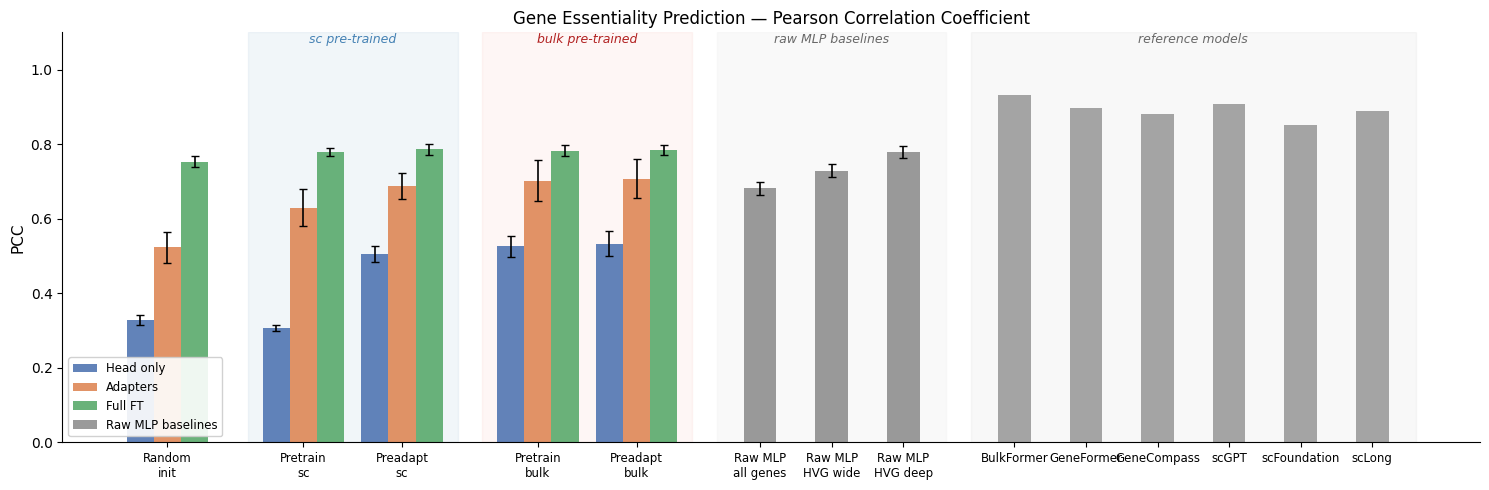

In [ ]:
task = "gene_essent"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "test_pcc_mean"
metric_std = "test_pcc_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

ref_models = [
    ("BulkFormer",   bulkformer_pcc_mean,   None),
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scGPT",        scgpt_pcc_mean,        None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
ref_start = (max(baseline_x.values()) + 0.9) if baseline_x else 4.8
ref_spacing = 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Raw MLP baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw MLP baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.003, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("PCC", fontsize=11)
ax.set_title("Gene Essentiality Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Survival prediction

In [ ]:
bulkrnabert_weighted_c_mean = 0.621
bulkrnabert_weighted_c_sd = 0.015


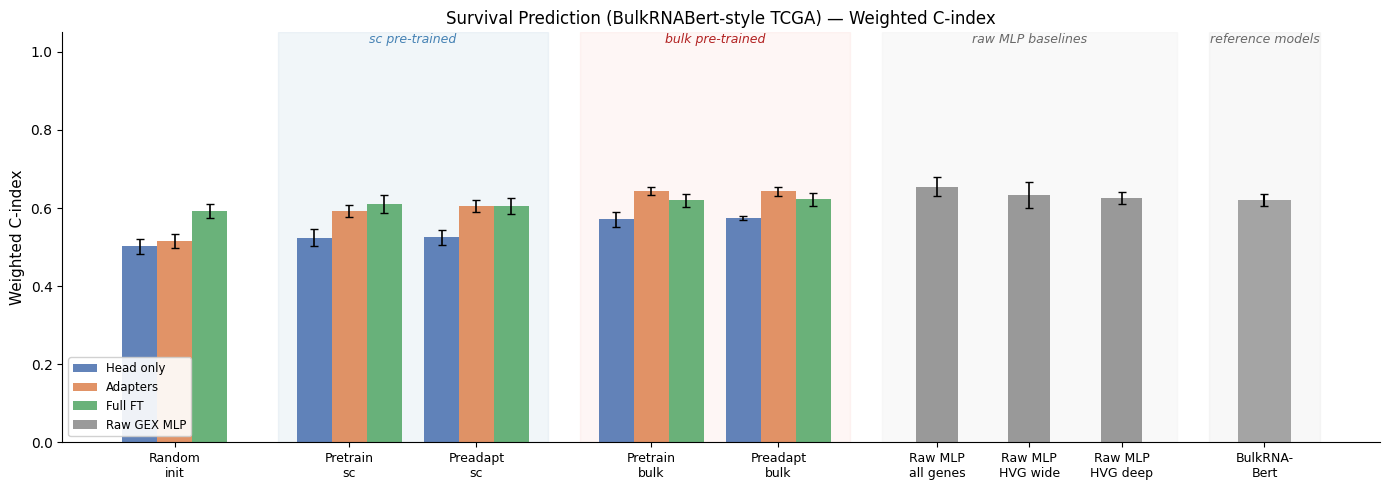

In [ ]:
task = "surv_pred"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_candidates = [
    ("test_cohort_weighted_c_index_mean", "test_cohort_weighted_c_index_std"),
    ("test_weighted_c_index_mean", "test_weighted_c_index_std"),
]
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def select_metric(df):
    for mean_col, std_col in metric_candidates:
        if mean_col in df.columns:
            return mean_col, std_col
    return None, None


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    for candidate in baseline_aliases.get(variant, [variant]):
        path = f"{base}/{candidate}/{task}_{candidate}_evaluation_metrics.csv"
        if os.path.exists(path):
            df = pd.read_csv(path, comment="#").set_index("model")
            metric_mean, _ = select_metric(df)
            if metric_mean is not None:
                return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No survival prediction evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start, baseline_spacing = 4.8, 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
brnabert_x = (max(baseline_x.values()) + 0.9) if baseline_x else 4.8

fig, ax = plt.subplots(figsize=(14, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    metric_mean, metric_std = select_metric(df)
    if metric_mean is None:
        continue
    for model, xc in centers.items():
        if model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3, alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    df = baseline_dfs[variant]
    metric_mean, metric_std = select_metric(df)
    row = df.loc["raw_mlp"] if "raw_mlp" in df.index else df.iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3, color="#8C8C8C", alpha=0.88,
           label="Raw GEX MLP" if variant == available_baselines[0] else "", error_kw={"linewidth": 1.2})

ax.bar(brnabert_x, bulkrnabert_weighted_c_mean, bar_w * 1.5, yerr=bulkrnabert_weighted_c_sd, capsize=3, color="#999999", alpha=0.88, label="_nolegend_")

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo, ref_hi = brnabert_x - 0.35, brnabert_x + 0.35
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.05)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.001, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.001, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.001, "raw MLP baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.001, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values()) + [brnabert_x]
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + ["BulkRNA-\nBert"]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel("Weighted C-index", fontsize=11)
ax.set_title("Survival Prediction (BulkRNABert-style TCGA) — Weighted C-index", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Survival prediction (SurvBoard)


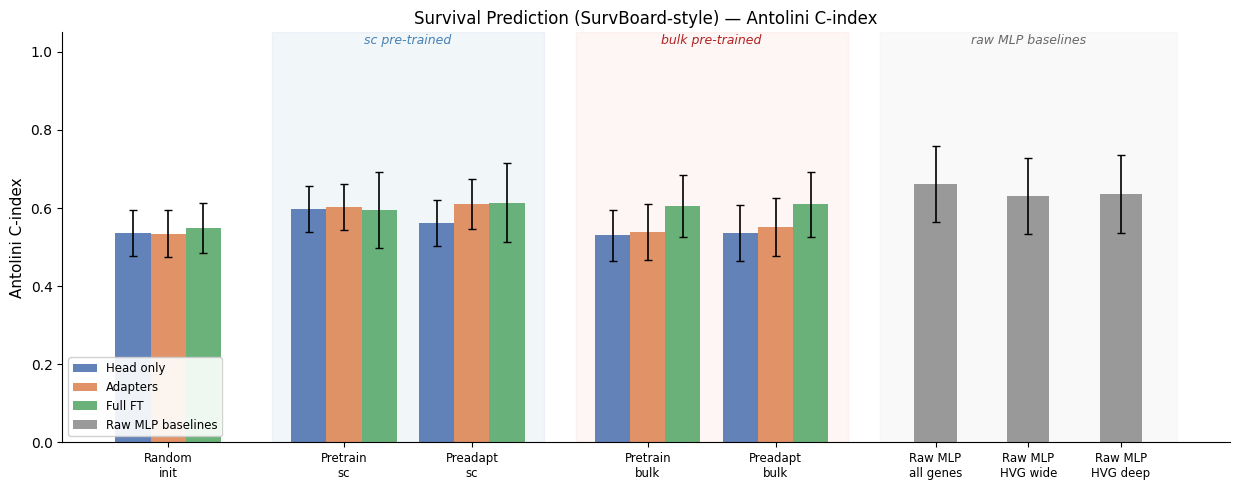

In [ ]:
task = "surv_pred_survboard"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "test_antolini_cindex_mean"
metric_std = "test_antolini_cindex_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

fig, ax = plt.subplots(figsize=(12.5, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Raw MLP baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.05)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw MLP baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values())
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("Antolini C-index", fontsize=11)
ax.set_title("Survival Prediction (SurvBoard-style) — Antolini C-index", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Survival prediction (binary)

In [ ]:
bulkformer_auroc_mean = 0.747
geneformer_auroc_mean = 0.647
genecompass_auroc_mean = 0.709
scgpt_auroc_mean = 0.723
scfoundation_auroc_mean = 0.726
sclong_auroc_mean = 0.584


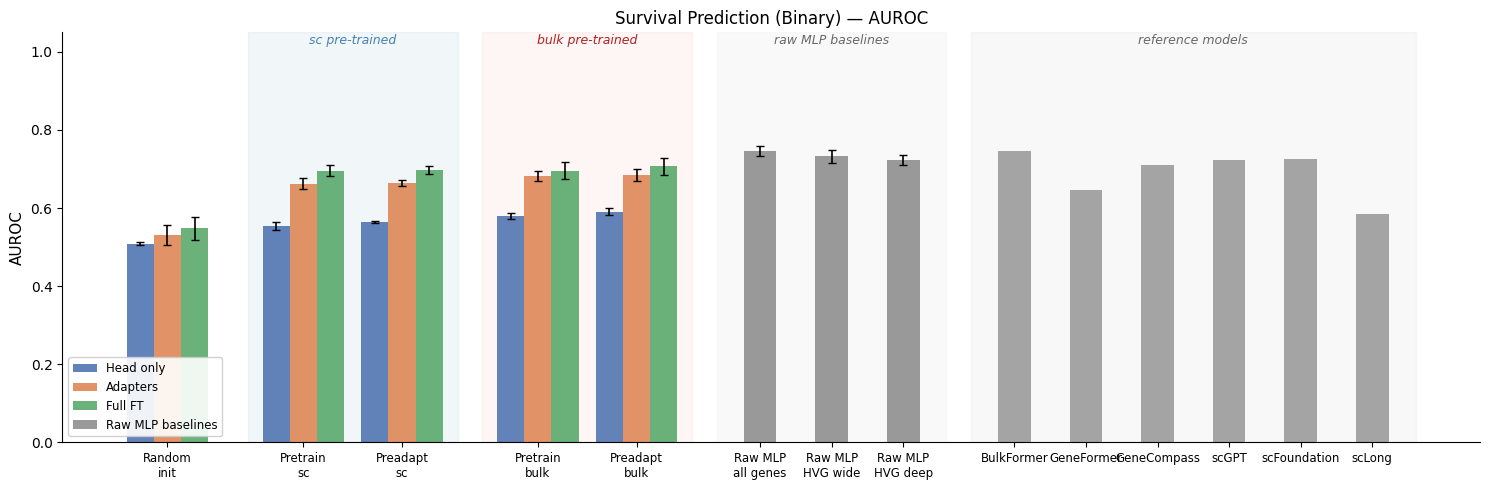

In [ ]:
task = "surv_pred_binary"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "auroc_mean"
metric_std = "auroc_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_hvg1199_deep", "Raw MLP\nHVG deep"),
]


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_baseline(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path, comment="#").set_index("model")
        if metric_mean in df.columns:
            return df
    return None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = {variant: load_baseline(variant) for variant, _ in baseline_specs}
available_baselines = [variant for variant, _ in baseline_specs if baseline_dfs[variant] is not None]
if not available_modes and not available_baselines:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 4.8
baseline_spacing = 0.58
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}

ref_models = [
    ("BulkFormer",   bulkformer_auroc_mean,   None),
    ("GeneFormer",   geneformer_auroc_mean,   None),
    ("GeneCompass",  genecompass_auroc_mean,  None),
    ("scGPT",        scgpt_auroc_mean,        None),
    ("scFoundation", scfoundation_auroc_mean, None),
    ("scLong",       sclong_auroc_mean,       None),
]
ref_start = (max(baseline_x.values()) + 0.9) if baseline_x else 4.8
ref_spacing = 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Raw MLP baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.05)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "raw MLP baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.003, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + list(baseline_x.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_title("Survival Prediction (Binary) — AUROC", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
